In [194]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

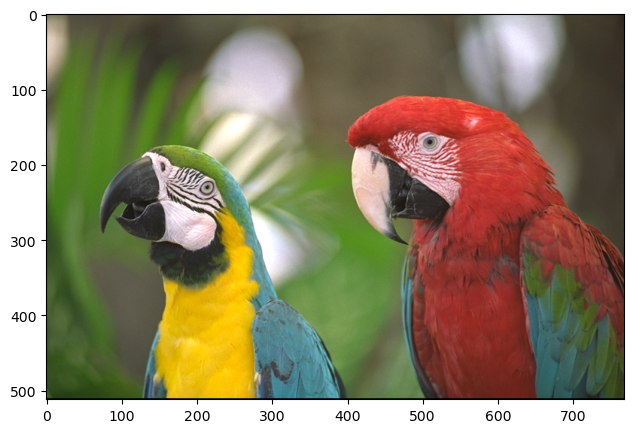

In [207]:
# Load image
img = cv2.imread('kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Cast the image to float
img = img.astype(np.float32) / 255.0
# Plot it
plt.imshow(img)



(512, 768, 3)


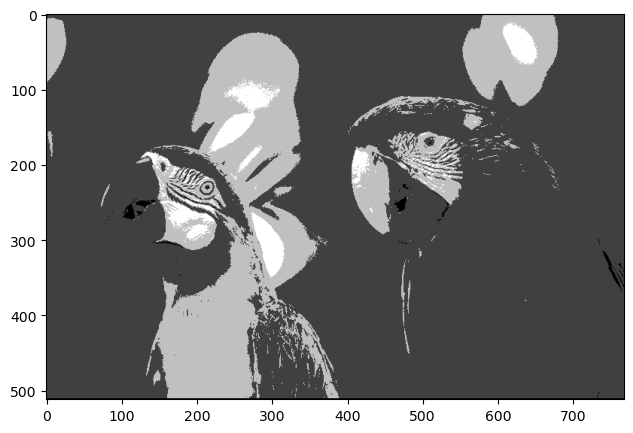

In [210]:
# Black, dark gray, light gray, white
# colors = np.array([[0, 0, 0],
#                    [64, 64, 64],
#                    [192, 192, 192],
#                    [255, 255, 255]], dtype=np.float32)/255.0

# colors = np.array([[255, 0, 0],
#                    [0, 255, 0], 
#                    [0, 0, 255]], dtype=np.float32)/255.0

colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]], dtype=np.float32) / 255.0


def closerColor(colors, pixel):
    distances = np.linalg.norm(colors - pixel, axis=1)
    closest_index = np.argmin(distances)
    return colors[closest_index];

# Prepare for quantization
rows, cols, channels = img.shape

quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        pixel = img[r][c]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        quantized[r, c, :] = closerColor(colors, pixel)

quantized = np.clip(quantized * 255, 0, 255).astype(np.uint8)
print(quantized.shape)
plt.imshow(quantized)

In [209]:
def avg_quant_error(img, quantized):
    orig = img.astype(np.float32)
    dith = quantized.astype(np.float32)
    errors = np.linalg.norm(orig - dith, axis=2)
    return np.mean(errors)

print("avg_quant_error : ", avg_quant_error(img, quantized))

avg_quant_error :  160.78947


(<Axes: title={'center': 'dithering'}>,
 Text(0.5, 1.0, 'dithering'))

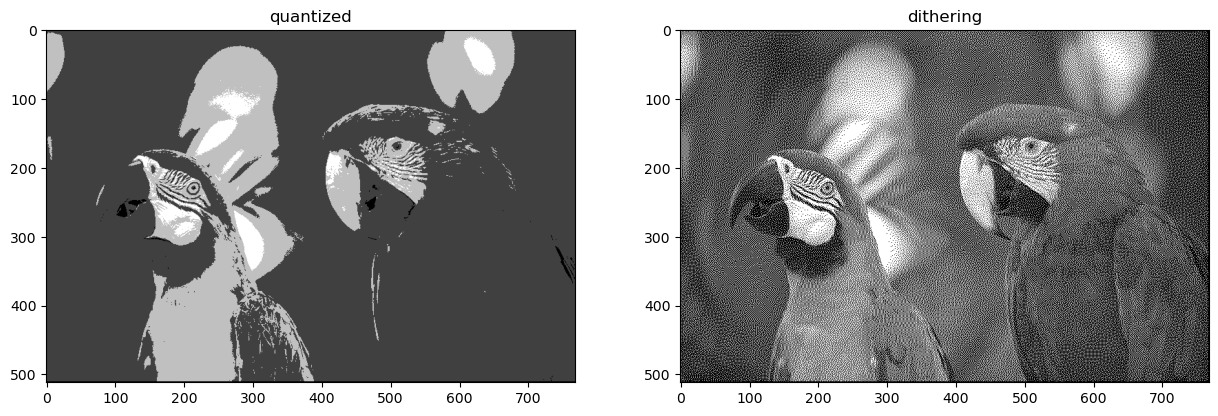

In [211]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)


# colors = np.array([[0, 0, 0],
#                    [64, 64, 64],
#                    [192, 192, 192], 
#                    [255, 255, 255]], dtype=np.float32)/ 255.0

# colors = np.array([[255, 0, 0],
#                    [0, 255, 0], 
#                    [0, 0, 255]], dtype=np.float32)/ 255.0

colors = np.array([[0, 0, 0],
                   [255, 255, 255]], dtype=np.float32)/ 255.0

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        # print(distances)
        new_pixel = colors[np.argmin(distances)]
        
        # Compute quantization error
        quant_error = pixel - new_pixel
        
        # Diffuse the quantization error accroding to the FS diffusion matrix
        img_tmp[r, c+1, :]     += quant_error * 7/16
        img_tmp[r+1, c-1, :]   += quant_error * 3/16
        img_tmp[r+1, c, :]     += quant_error * 5/16
        img_tmp[r+1, c+1, :]   += quant_error * 1/16
        
        # Apply dithering
        dithering[r, c, :] = new_pixel

# print(dithering)
dithering = np.clip(dithering * 255, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(quantized), plt.title("quantized")
plt.subplot(122), plt.imshow(dithering), plt.title("dithering")

In [214]:
# Compute average quantization error for dithered image

print('dithered quant error : ', avg_quant_error(img, dithering))

# Questions
# Which image has higher quantization error? Optimally quantized or dithered? Optimal quantization has lover quantization error (160.78947). FS dithering (176.55986)
# Which image looks better to you? FS dithering image looks much better but has higher quant error
# Can you repeat the same process using only two colours: black and white? Show me :-) FS dithering still looks much better but I am bit suprised
# that it has lovest quant error (97.29772)

dithered quant error :  176.55986


black white quant error :  97.29772


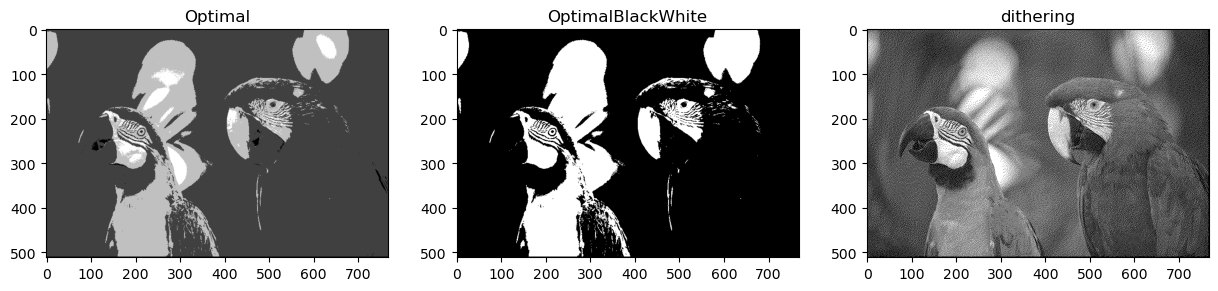

In [213]:
quantizedBlackWhite = np.zeros_like(img)


plt.rcParams['figure.figsize'] = [15, 5]

colors = np.array([[0, 0, 0],
                   [255, 255, 255]], dtype=np.float32)/ 255.0

# Apply quantization
for r in range(rows):
    for c in range(cols):
        pixel = img[r][c]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        quantizedBlackWhite[r, c, :] = closerColor(colors, pixel)

quantizedBlackWhite = np.clip(quantizedBlackWhite * 255, 0, 255).astype(np.uint8)

plt.subplot(131), plt.imshow(quantized), plt.title("Optimal")
plt.subplot(132), plt.imshow(quantizedBlackWhite), plt.title("OptimalBlackWhite")
plt.subplot(133), plt.imshow(dithering), plt.title("dithering")

print('black white quant error : ', avg_quant_error(img, quantizedBlackWhite))